In [1]:
import sys, os
os.chdir(os.path.abspath('..'))
sys.path.insert(0, os.getcwd())

# Data loading and plotting tutorial

## Prerequisite: run the example model first

This tutorial reads model output from `models/parameter_user/`. If that directory doesn't exist yet, generate it first by running, from the repo root:

```
conda activate orchard_env
python evolution.py --config parameter_examples/parameter_user.ini
```

Likewise, the SONORA-BOBCAT comparison further down expects `models/parameter_user_sonorabobcat/`. Run that one as well if you want to reproduce the comparison:

```
python evolution.py --config parameter_examples/parameter_user_sonorabobcat.ini
```

Each run takes a few minutes. The notebook `os.chdir(..)` to the repo root in the first cell, so all paths below are relative to the repo root.

## Data loading

The file `load_models.py` is designed to load, read, and retain the data. This can be used either for plotting your own plots (shown below), or for plotting standard plots using `plot_class.py` (next section).

By default, `parameters_default.ini` saves the data in `.h5` format, but you may choose to save the data in `.txt` format by setting `save_hdf5 = False`. Both `load_models.py` and `plot_class.py` detect the format automatically.

To read the data with `load_models.py`, pass a list of parameter file paths to `load_models.load(paths)` like so:

In [2]:
import load_models

paths = [
    "parameter_examples/parameter_user.ini", # Fully adiabatic and homogeneous 1 MJ model
]

models = load_models.load(paths)


Reading files...
Finished reading files...


In [3]:
models[0].keys()

dict_keys(['kcore_saved', 'kcore_fe_saved', 'read_verbose', 'mass_grid', 'mass_norm', 'mass_norm_i', 'rad', 'press', 'rho', 'temp', 'S', 'Y', 'Z', 'Ym', 'Z1m', 'Z2m', 'f_rock', 'conv_flux', 'rad_flux', 'semi_flux', 'Lambda_cond_i', 'Lambda_rad_i', 'bracket_dsdr', 'dsdy_prho', 'dsdz_prho', 'dsdy_pt', 'dsdz_pt', 'brunt', 'R0_inv', 'mantle_phases', 'data_age', 'data_tint', 'data_teff', 'data_grav', 'data_rad', 'data_omega', 'luminosity', 'data_Y_atm', 'data_Z_atm', 'J2_TOF', 'J4_TOF', 'J6_TOF', 'oblat_TOF', 'Req_TOF', 'Rpol_TOF', 'Rvol_TOF', 'data_I', 'deltaE', 'dE_S', 'energy', 'melt_fraction', 'data_kcore', 'data_kcore_fe'])

The data is then stored in `models`. The model index (`models[i]`) accesses the i-th model listed in `paths`. Each profile (temperature profile, pressure profile) and timeseries quantity (Teff, radius, etc.) is also stored as attributes on `models`. `models` also keeps the metadata from your config file.

Two equivalent access styles are shown in the next cell. Pick whichever reads more naturally:

- *Attribute style*: `models.temp[0]` returns the temperature profile array of model 0 (handy when iterating over many models or fields by name).
- *Per-model dict style*: `models[0]['rho']` returns the density profile of model 0 (handy when you want one model's full record in a single object).

Both styles point to the same underlying arrays.

In [4]:
# Access like plot_class-style lists:
T0 = models.temp[0] # temperature data for 0th model
P0 = models.press[0] # pressure data for 0th model
age0 = models.data_age[0] # data age array (in seconds) of the 0th model
rad0 = models.data_rad[0] # total radius data for 0th model
teff0 = models.data_teff[0] # effective temperature data for 0th model

# Or per-model dicts:
m0 = models[0] # model data for 0th model 
rho0 = m0["rho"] # density data for 0th model
meta0 = models.metadata[0]

## Plotting

We can now start plotting the timeseries:

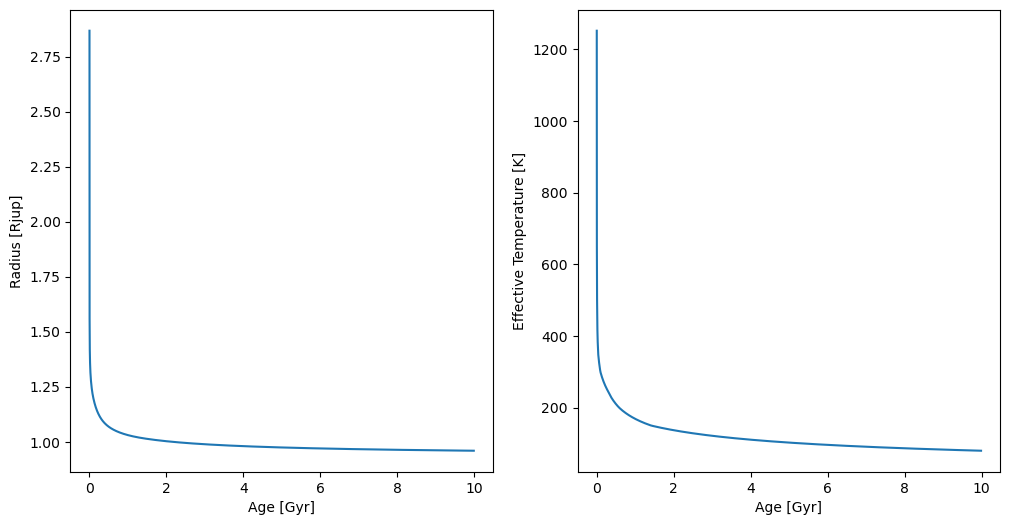

In [5]:
from utils import const 
import matplotlib.pyplot as plt

age0_gyr = age0 * const.s_to_Gyr # in Gyr instead of seconds
rad0_rjup = rad0 / const.rjup # in Jupiter radii instead of cm

plt.figure(figsize=(12, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

ax1.plot(age0_gyr, rad0_rjup)
ax2.plot(age0_gyr, teff0)

ax1.set_xlabel("Age [Gyr]")
ax1.set_ylabel("Radius [Rjup]")

ax2.set_xlabel("Age [Gyr]")
ax2.set_ylabel("Effective Temperature [K]")

plt.show()

## Using `plot_class.py` for plotting and data access.

There are many quantities to plot. If you'd rather use our `plot_class.py` to get a quick view of your model, you can do so by following the examples below. The example directly below uses `still_plot` to plot your model at a given age in Gyrs:

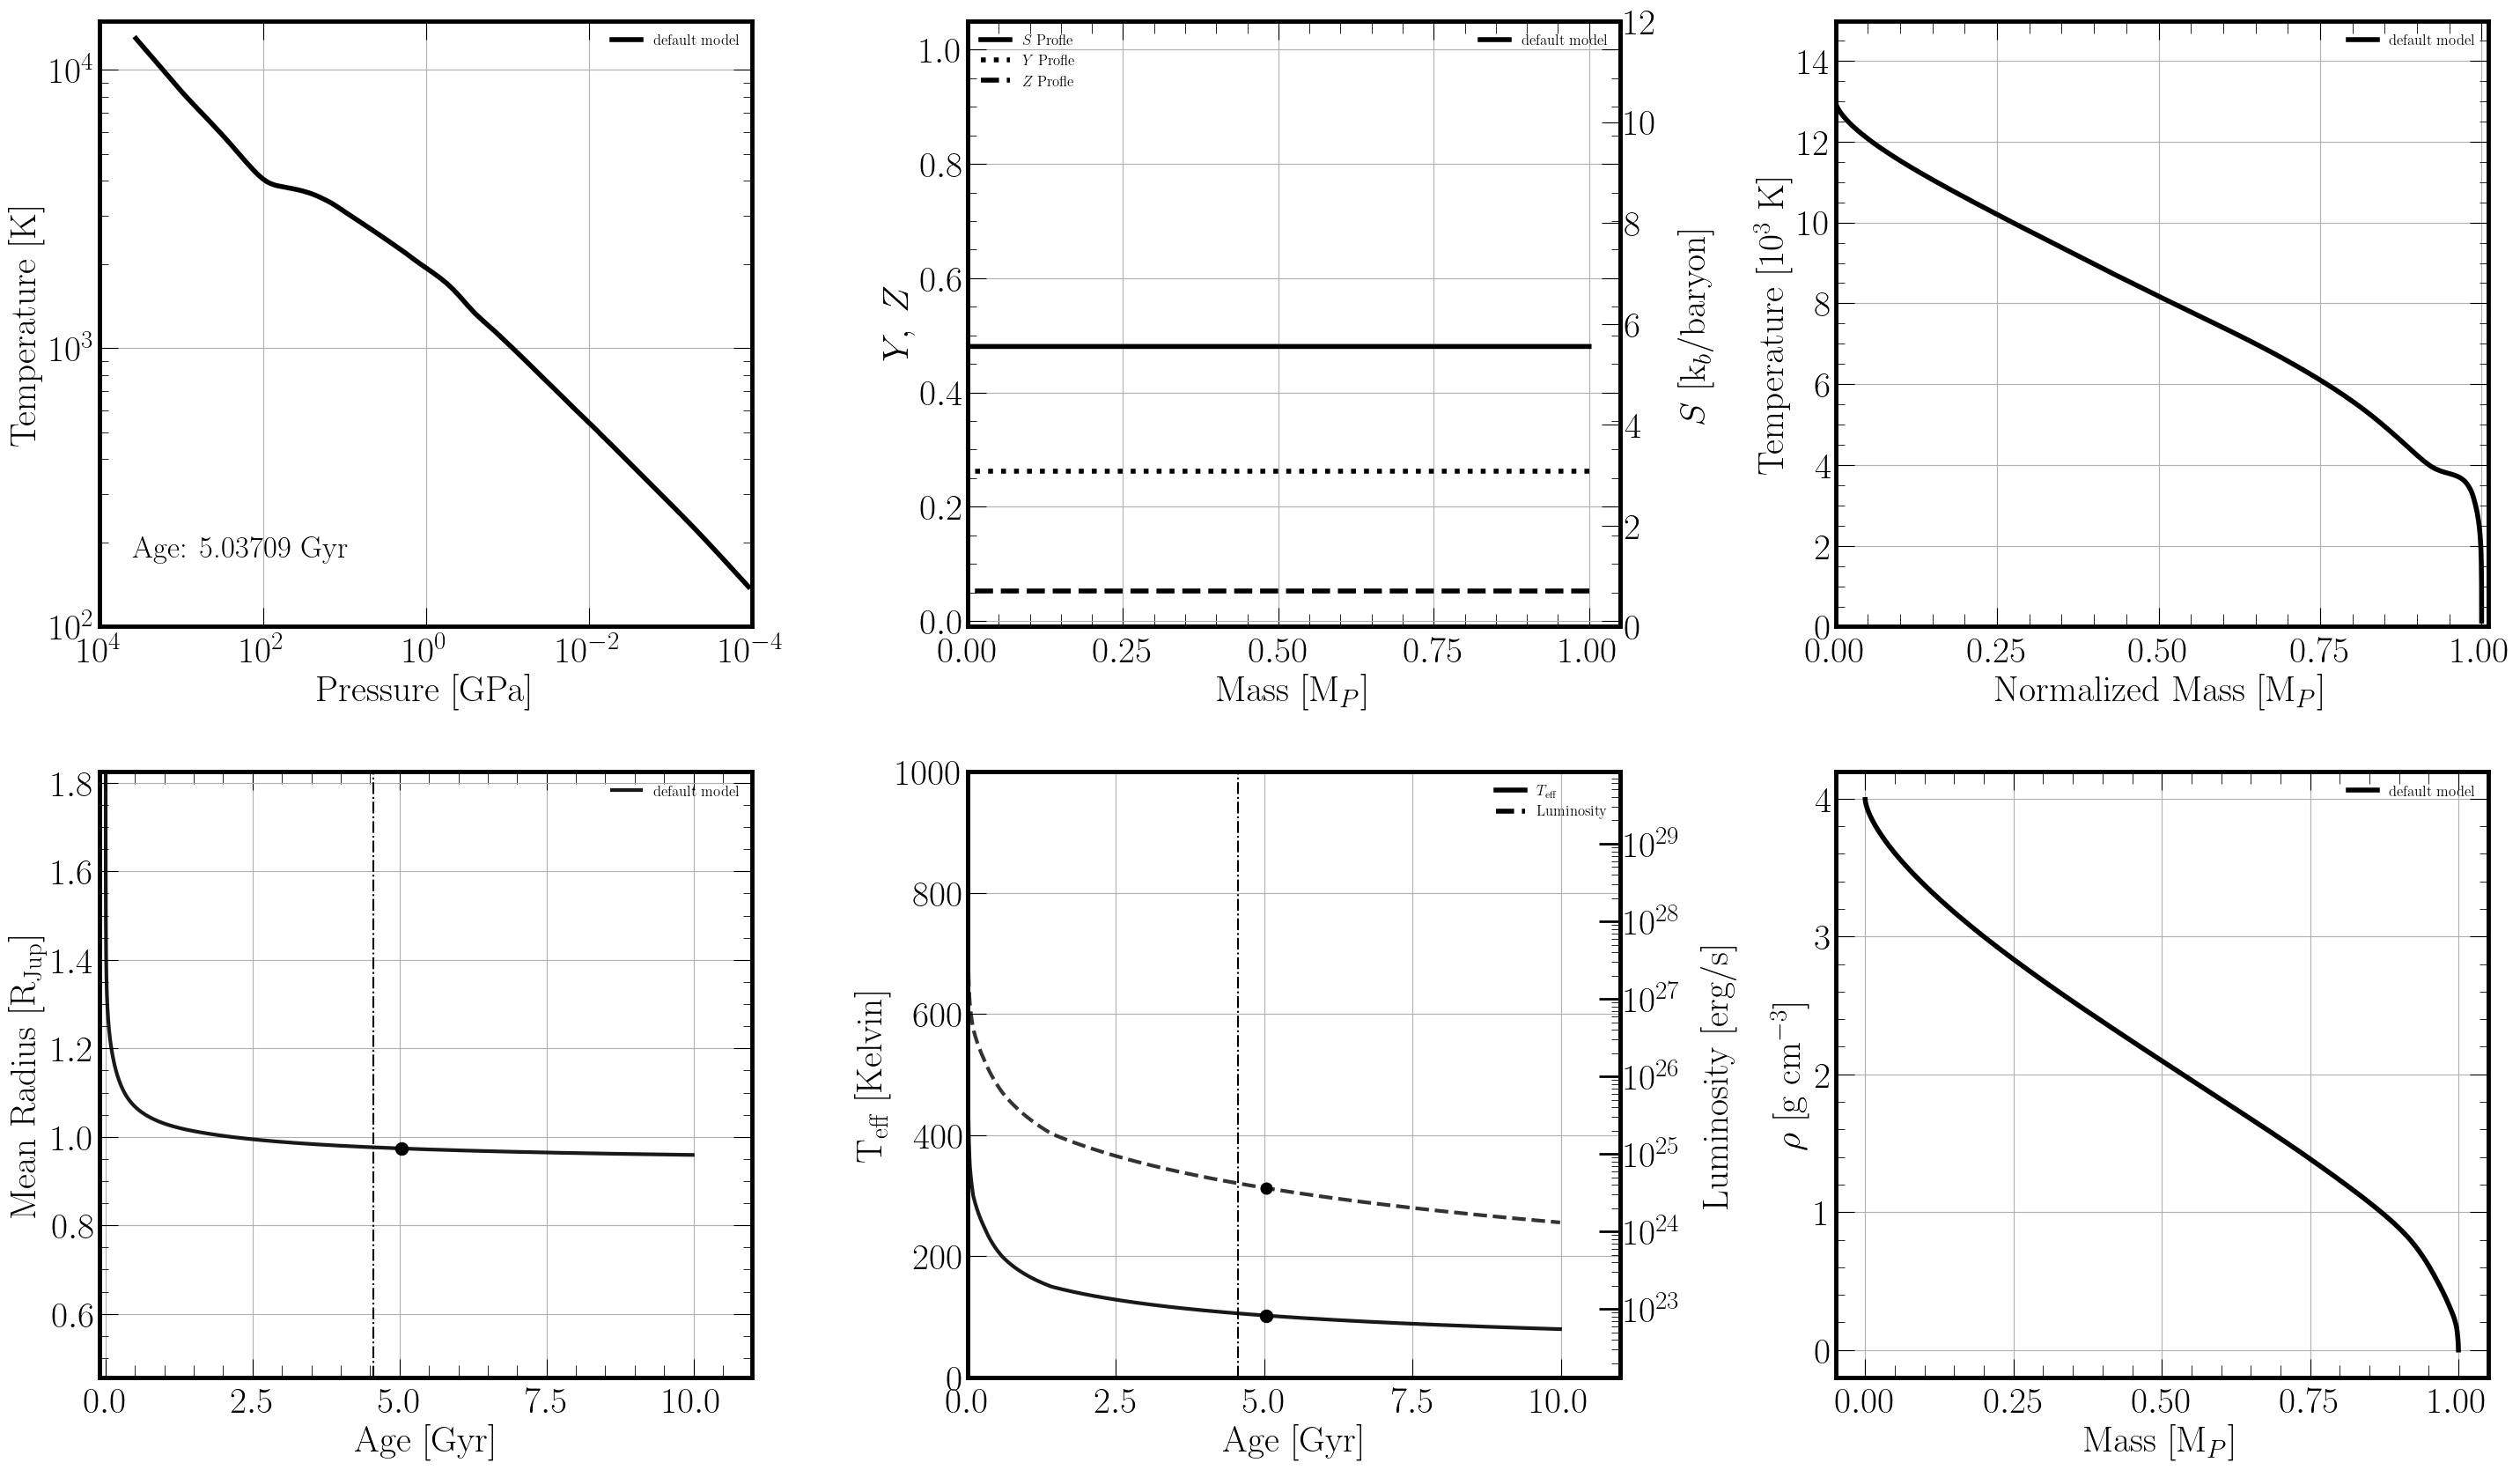

In [6]:
import plot_class

paths = [
    "parameter_examples/parameter_user.ini",
]


init = plot_class.init_plot(paths = paths)

labels = [
    r'default model',
]


init.still_plot(
    age = 5.0, # in Gyr
    labels = labels,
)


... or you can use `age_plot()` to plot different ages of the same model:

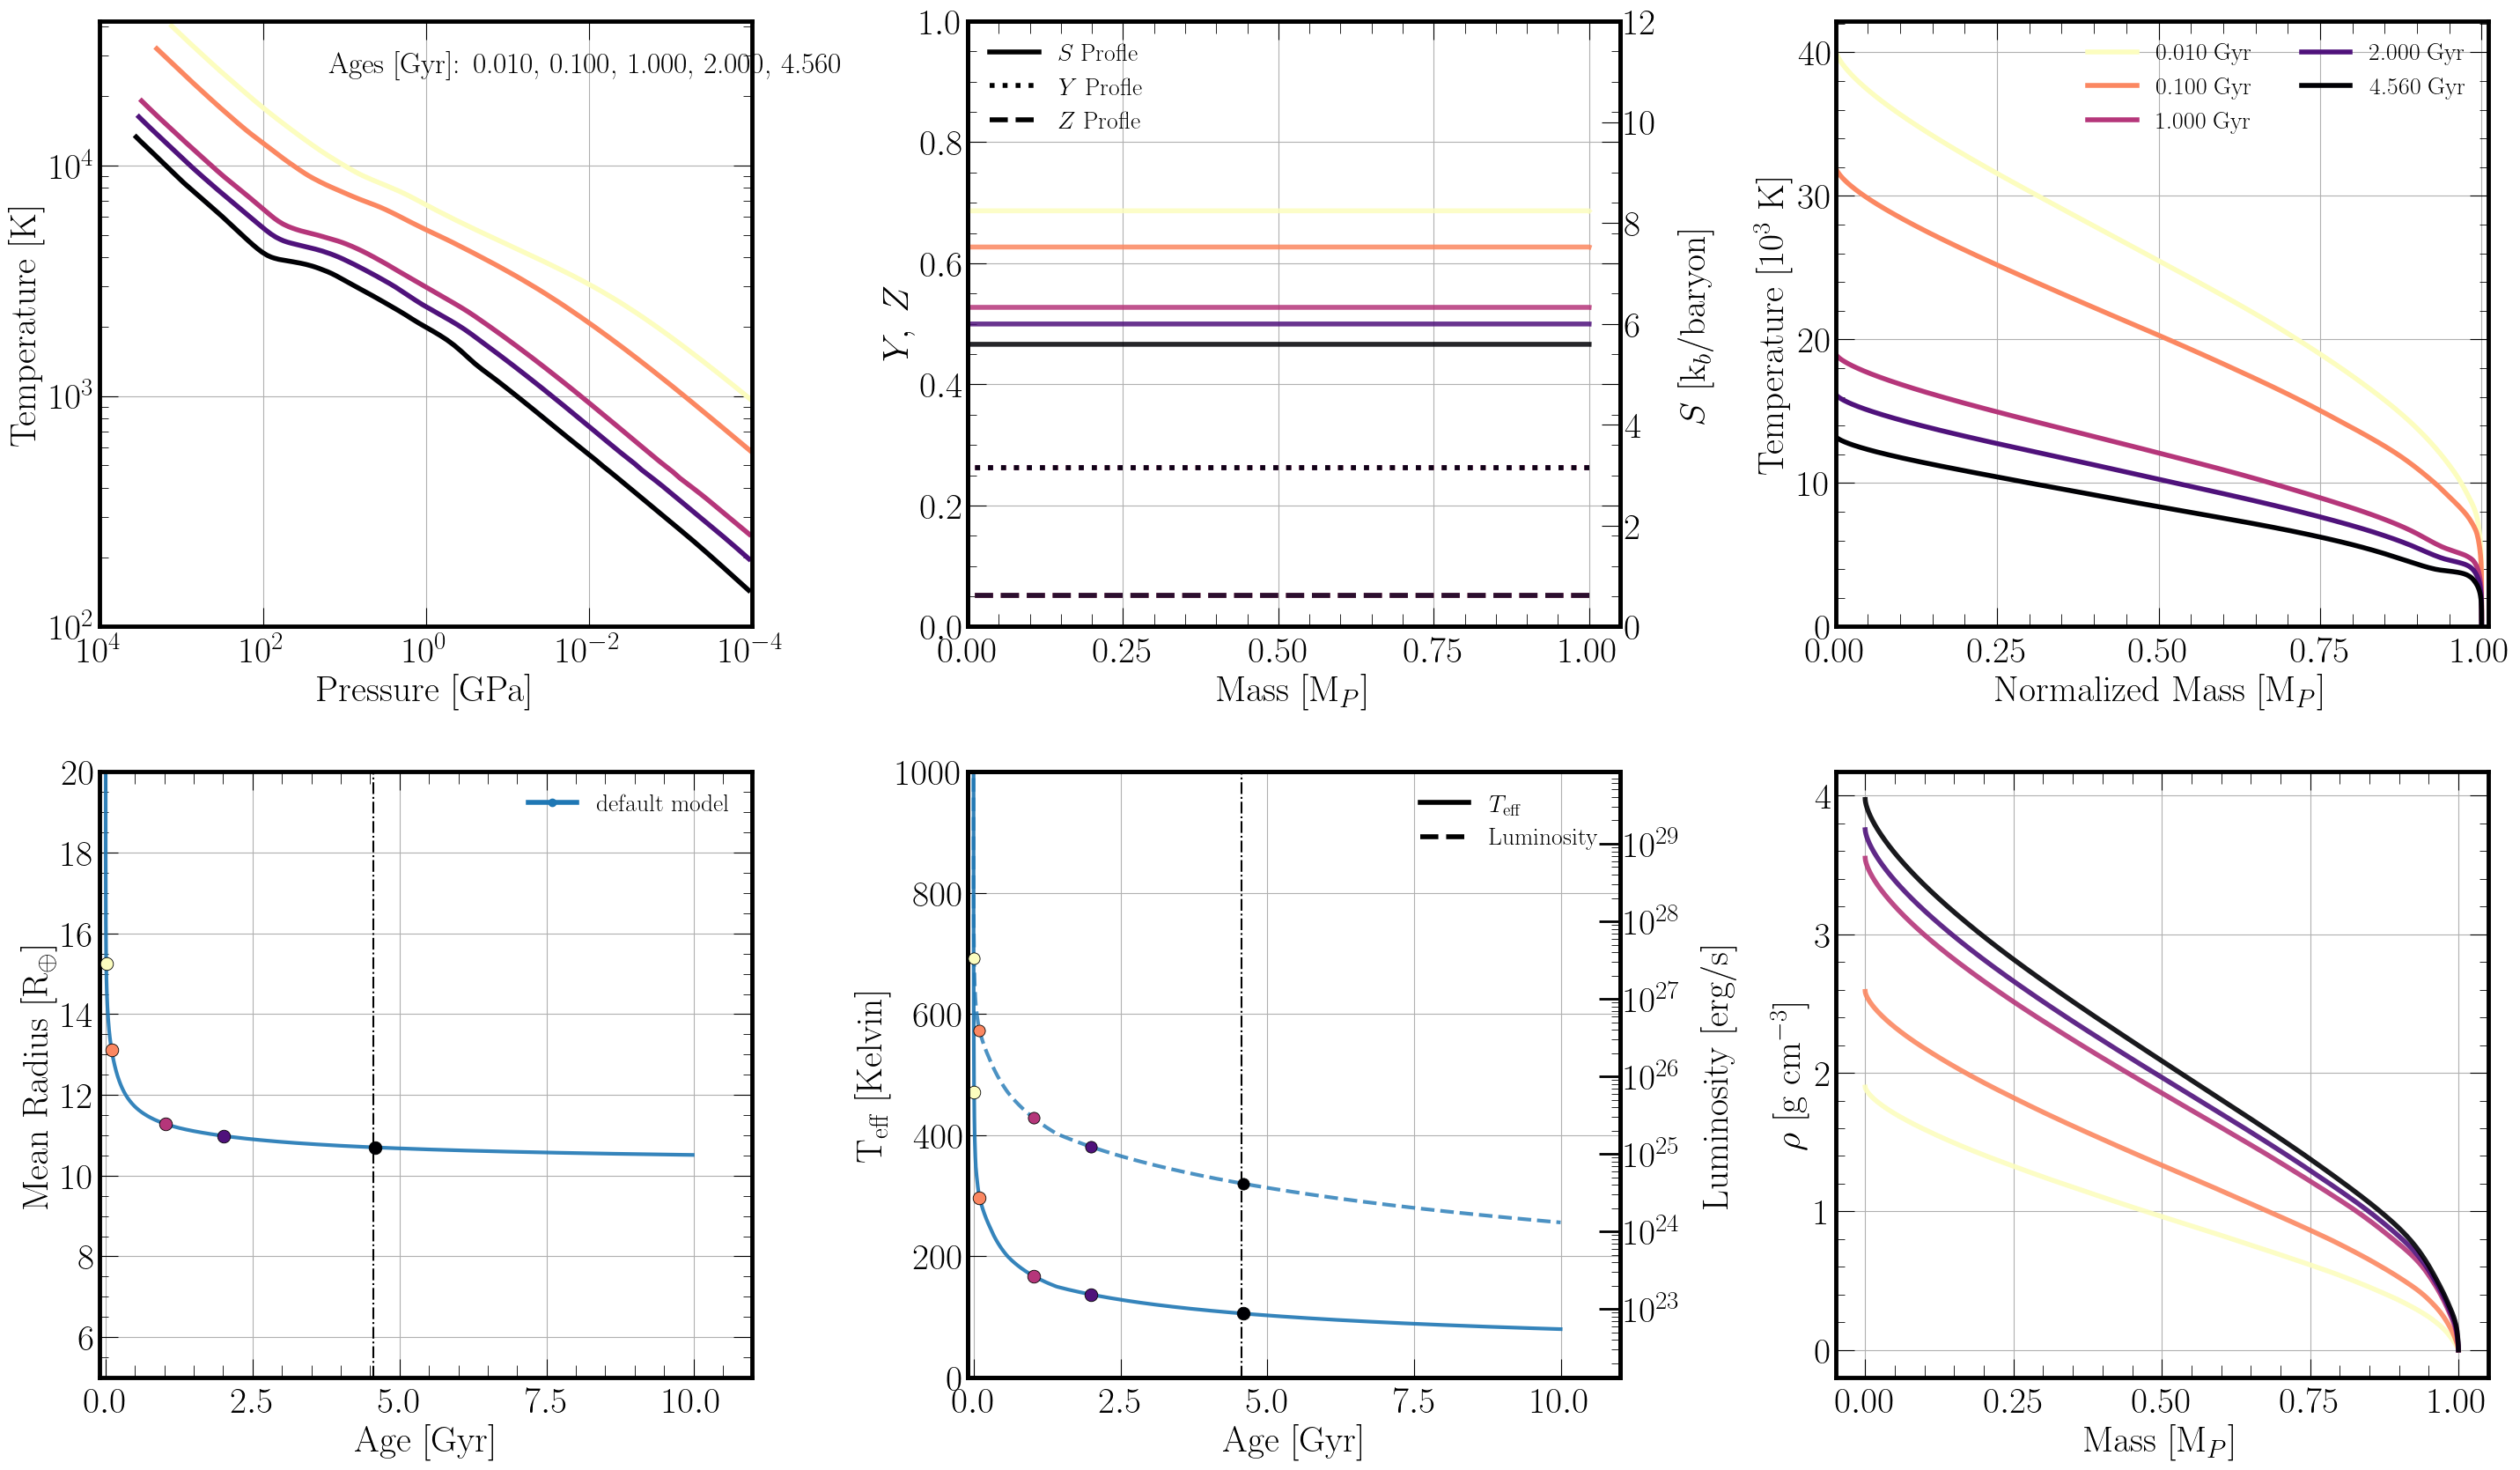

In [7]:
import plot_class

paths = [
    "parameter_examples/parameter_user.ini",
]


init = plot_class.init_plot(paths = paths)

labels = [
    r'default model',
]


init.age_plot(
    ages=[0.01, 0.1, 1.0, 2.0, 4.56],
    output_file='age_compare',
    labels=labels,
    save=False, # option to save the plot in the plots/ folder
    leg_size=20,
)


If you're plotting only one model, `age_plot()` will use `magma_r` as the colormap. If you're plotting more than one model, then `age_plot()` will default to using dark-faint color gradient for each model to mark ages using the default `matplotlib` color sequence. Let's plot the same model above with a different colormap.

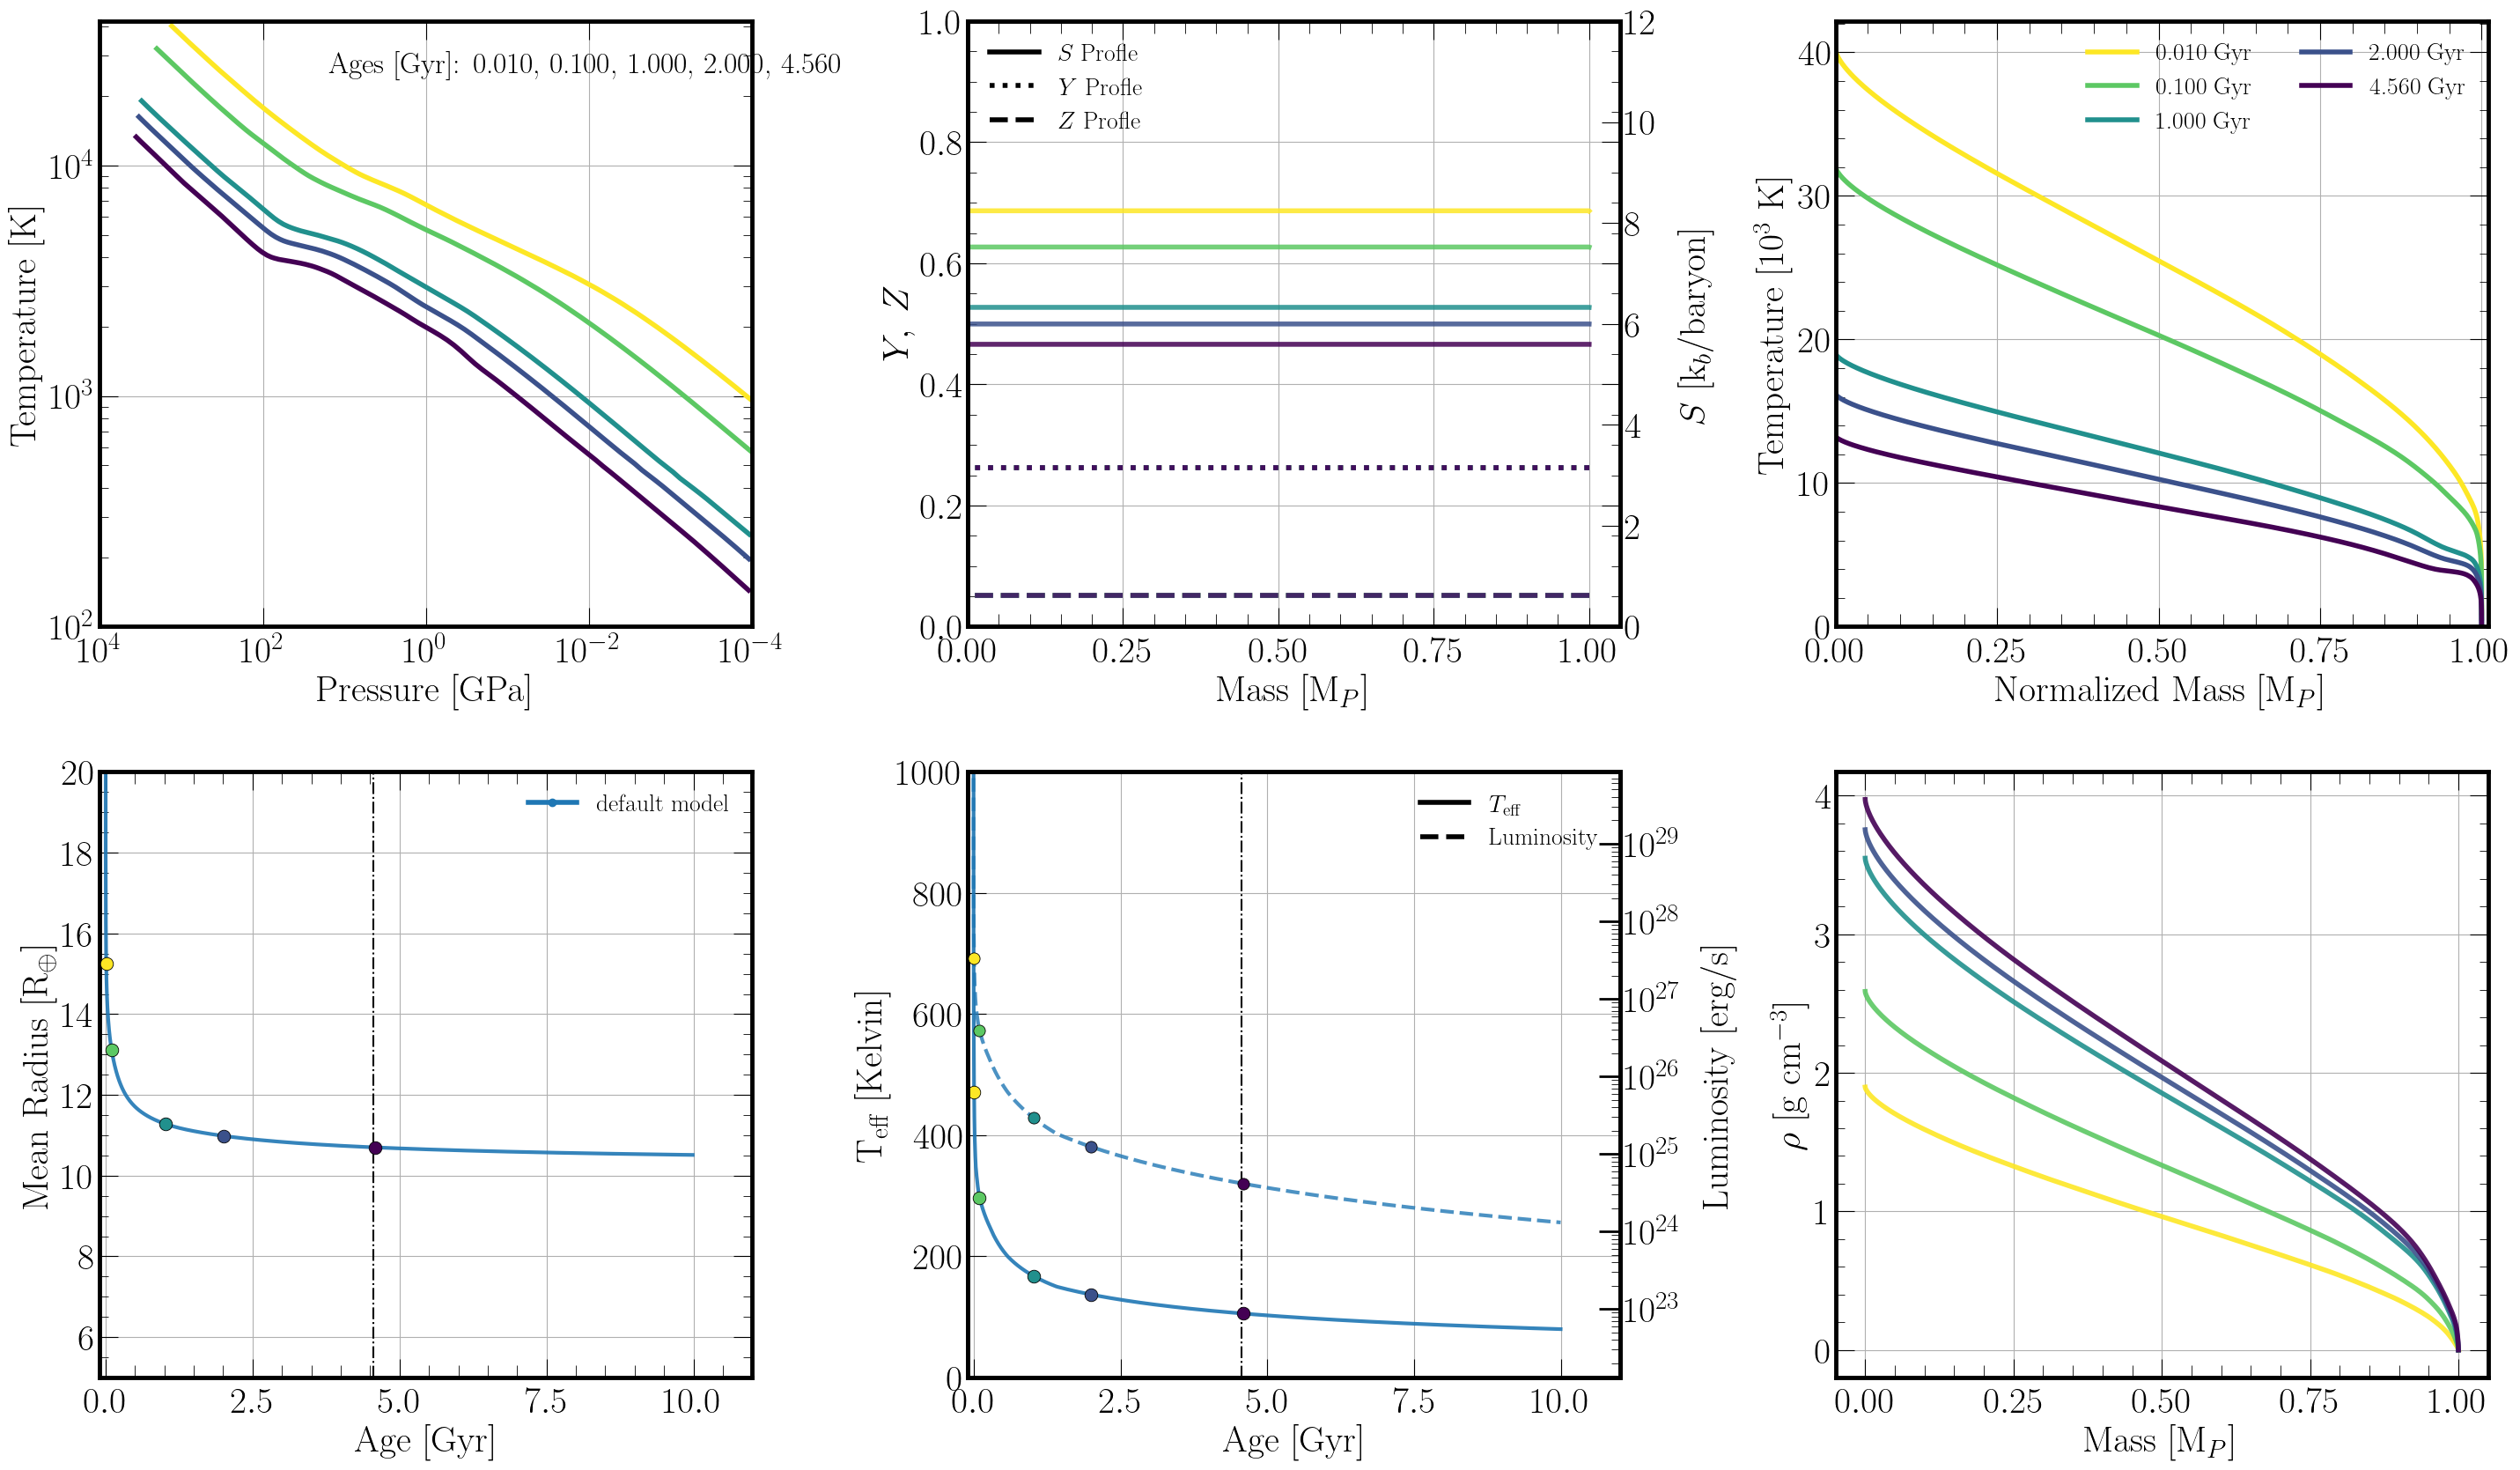

In [8]:
import plot_class

paths = [
    "parameter_examples/parameter_user.ini",
]


init = plot_class.init_plot(paths = paths)

labels = [
    r'default model',
]


init.age_plot(
    ages=[0.01, 0.1, 1.0, 2.0, 4.56],
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    cmap = 'viridis_r' # 'reversed viridis' (preference for reversed colors to darken later ages-- up to you though!)
)


If, instead, you'd rather plot a single snapshot and compare across different models (specified in paths list), then fainter versions of specific colors will be used.


 I've ran the same `parameter_user` file with the SONORA-BOBCAT (Marley et al. 2021) atmosphere models as a separate config file and named it `parameter_user_sonorabobcat.ini`. This can be done by simply setting `bc_atm = m21` in the `[boundary_condition]` section of your config file. 

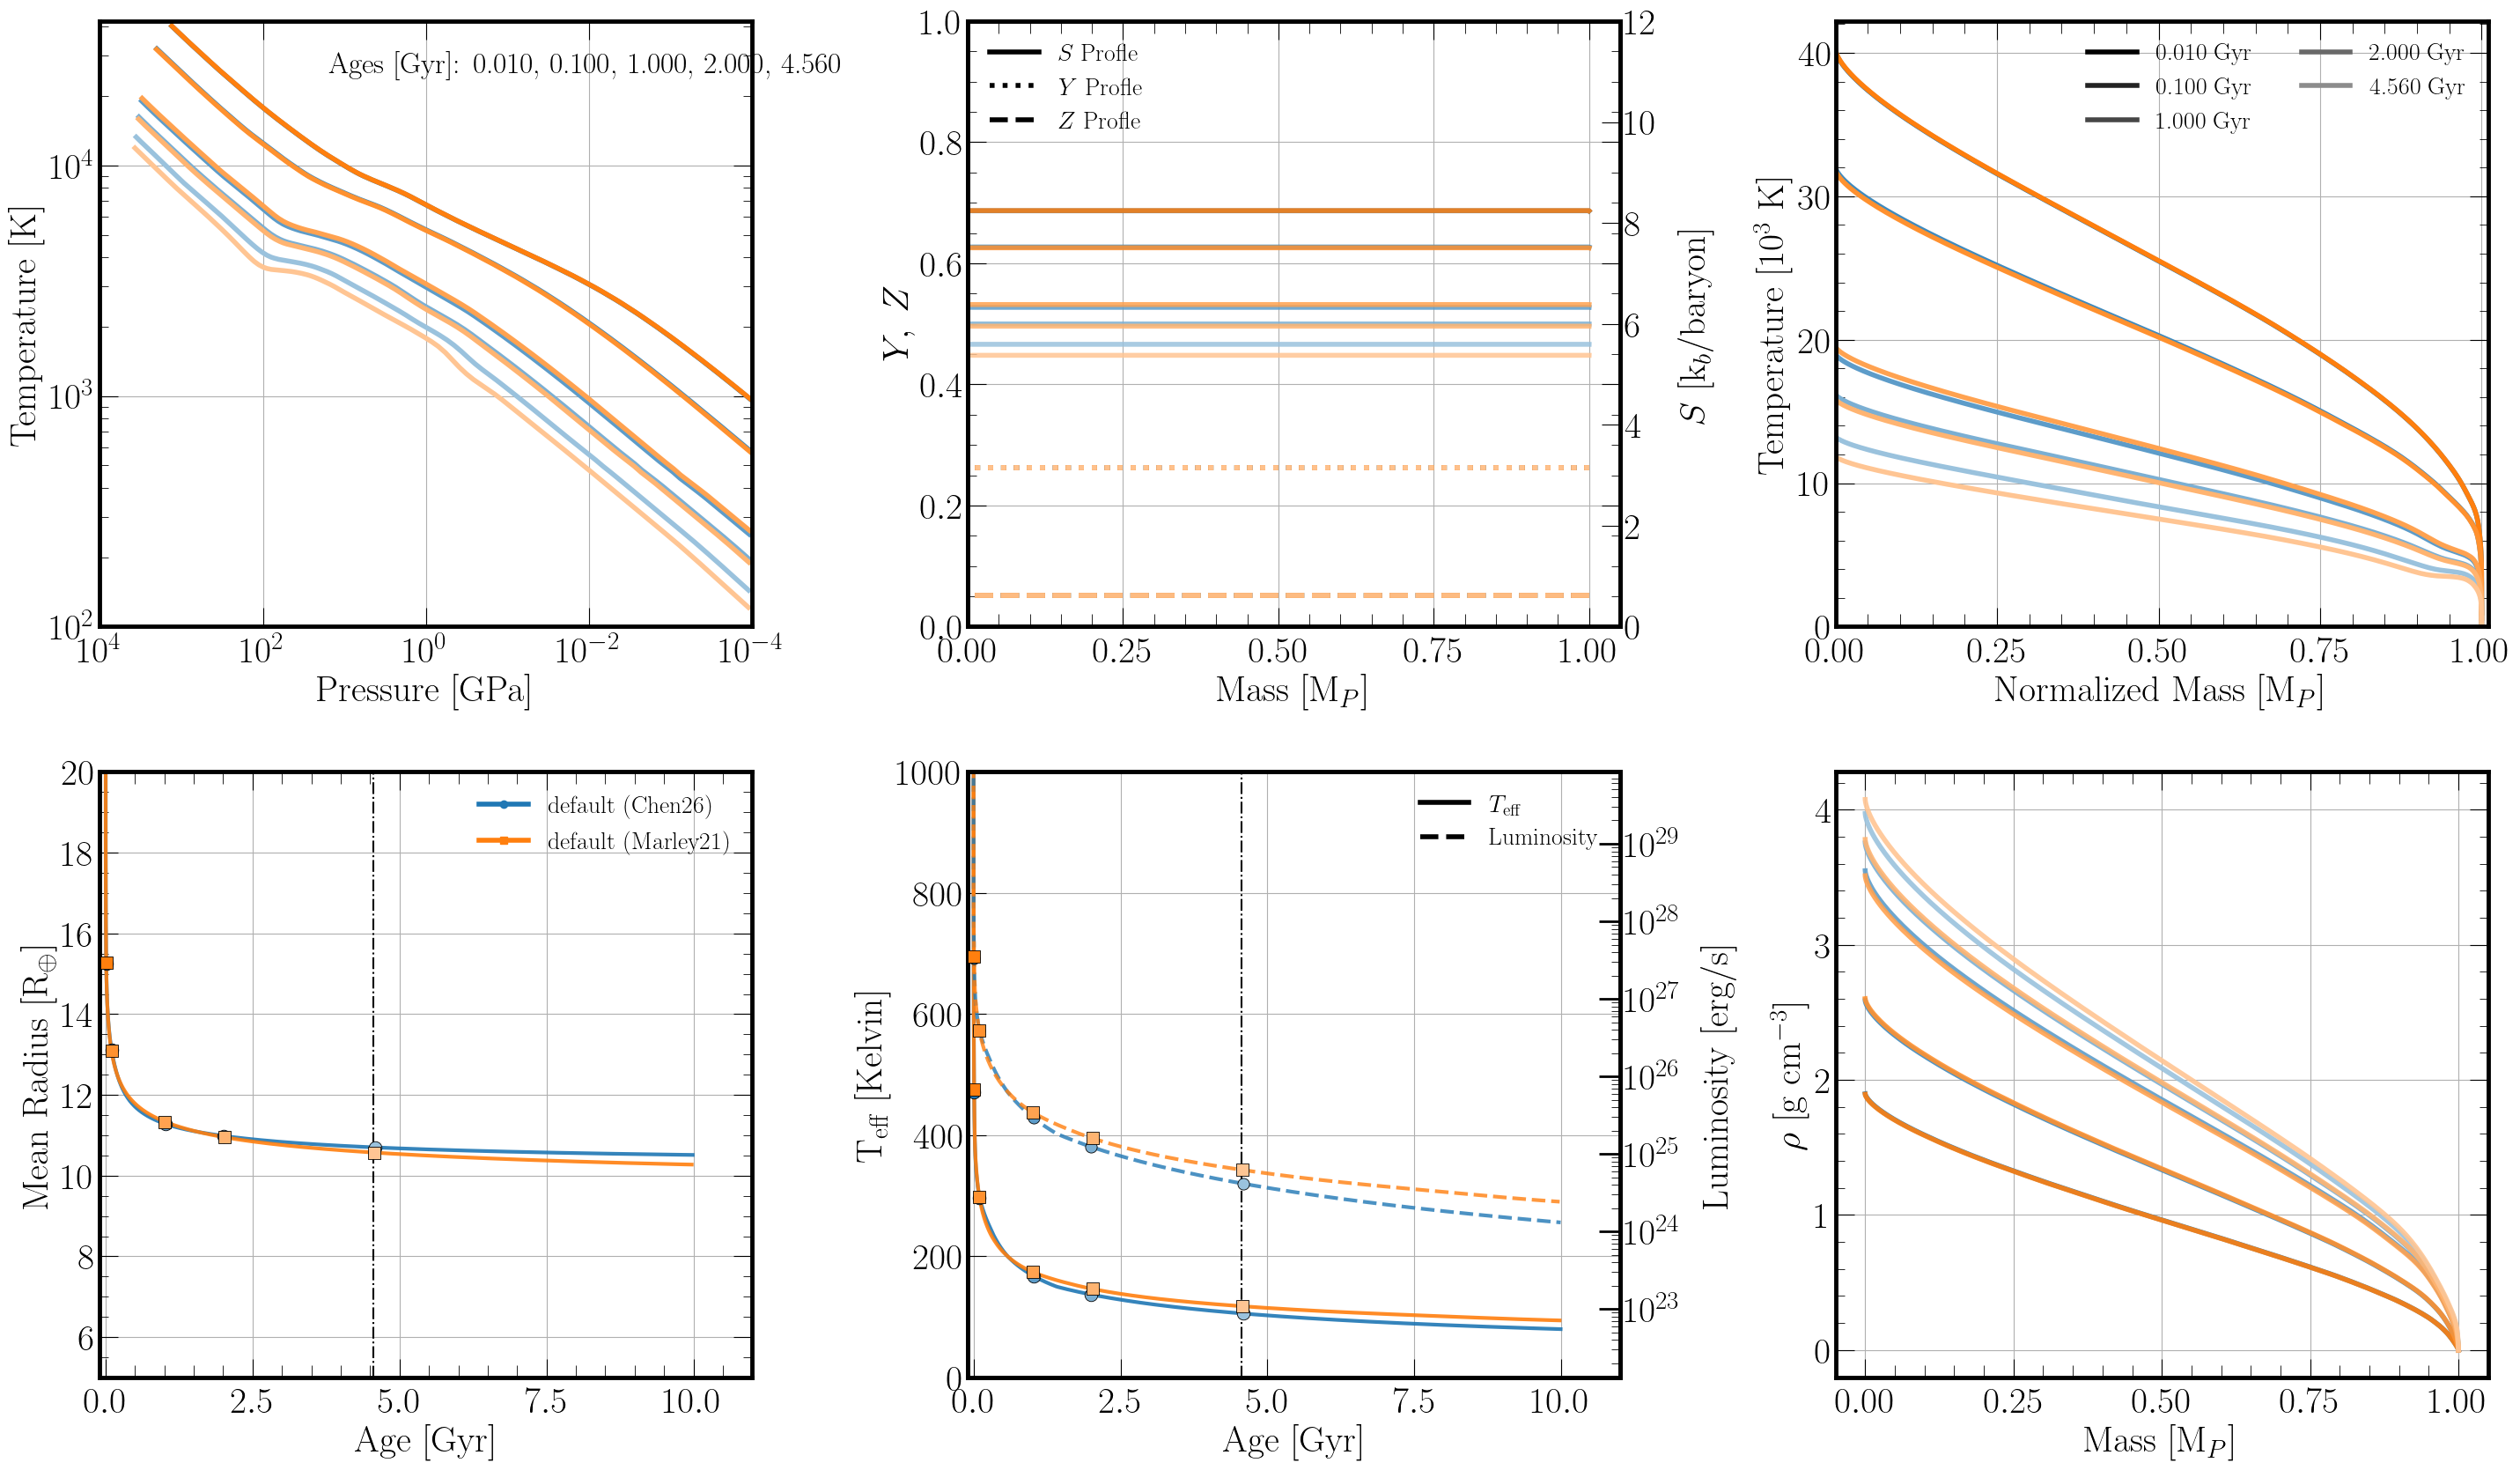

In [9]:
import plot_class

paths = [

    'parameter_examples/parameter_user.ini',
    'parameter_examples/parameter_user_sonorabobcat.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'default (Chen26)',
    r'default (Marley21)',
]

init.age_plot(
    ages=[0.01, 0.1, 1.0, 2.0, 4.56],
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
)


**NOTE**: These plotting tools are provided by the developers (Rob, Yubo) for user convenience, diagnostics, and debugging purposes. They are not meant to be publication quality, nor presentation quality. We do not suggest using these simple plotting tools for your papers nor presentations. Instead, you can use `load_models()` above and use your own plotting styles for those purposes.

This quick look lets us see the differences in the temperature and density profiles (left columns), and differences in the radius, effective temperature, and luminosity profiles (center and right-center). Since these are adiabatic and homogeneous examples, the entropy (S) profiles are flat in the upper-right corner (solid), and so are the Z (dashed) and Y (dotted) profiles.

By default, both `age_plot()` and `still_plot()` show 6 panels:

| Panel | Quantity |
|---|---|
| Upper left | $\log T$ vs. $\log P$, the planet's adiabat in EOS coordinates. |
| Upper center | Y, Z (and reference observed atmospheric values when `planet=Jupiter/Saturn`) vs. normalized mass. |
| Upper right | $T$, S (solid), Z (dashed), Y (dotted) vs. normalized mass. |
| Lower left | Mean radius vs. age (with reference Jupiter/Saturn radii overlaid when applicable). |
| Lower center | Effective temperature and luminosity vs. age. |
| Lower right | Surface intrinsic / equilibrium temperature decomposition. |

Both plots also support 4 and 9 panels, showing fewer or more profiles such as the Brunt-Väisälä frequency and the J-gravity harmonics (pass `plot_Js=True` to `init_plot()`; this is only meaningful if the model was run with `rotation = True` in its config).